# INLAB TASKS

# Task 1: Develop predictive regression models using Linear Regression techniques for continuous-valued data analysis

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

#Load the dataset
boston="https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
boston_df=pd.read_csv(boston)

#Define features and target details
features= [col for col in boston_df.columns if col!='medv']
x=boston_df[features]
y=boston_df['medv']

#Split data into training and test validation split
x_train,x_test,y_train,y_test= train_test_split(x,y, test_size=0.20, random_state=42)

print("Dataset Dimensions (rows, cols):", boston_df.shape)
print("Missing values per column:\n", boston_df.isnull().sum())
print("\nFirst 3 rows of target data:")
print(y_train.head(3))


Dataset Dimensions (rows, cols): (506, 14)
Missing values per column:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

First 3 rows of target data:
477    12.0
15     19.9
332    19.4
Name: medv, dtype: float64


In [12]:
from sklearn.preprocessing import StandardScaler

#Standardize feature metrics
scale=StandardScaler()
x_train_scale= scale.fit_transform(x_train)
x_test_scale= scale.fit_transform(x_test)

print("Standardized training features mean (approx 0):", round(x_train_scale.mean(), 4))
print("Standardized training features std dev (approx 1):", round(x_train_scale.std(), 4))

Standardized training features mean (approx 0): -0.0
Standardized training features std dev (approx 1): 1.0


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model=LinearRegression()

#Train the model
lr_model.fit(x_train,y_train)

#Predict the model
y_pred=lr_model.predict(x_test)

#Calculate regression performance analysis
lr_mae = mean_absolute_error(y_test, y_pred)
lr_mse = mean_squared_error(y_test, y_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance Metrics")
print("-------------------------------------")
print(f"Mean Absolute Error (MAE)      : {lr_mae:.4f}")
print(f"Mean Squared Error (MSE)       : {lr_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {lr_rmse:.4f}")
print(f"R² Score                       : {lr_r2:.4f}")

Linear Regression Performance Metrics
-------------------------------------
Mean Absolute Error (MAE)      : 3.1891
Mean Squared Error (MSE)       : 24.2911
Root Mean Squared Error (RMSE) : 4.9286
R² Score                       : 0.6688


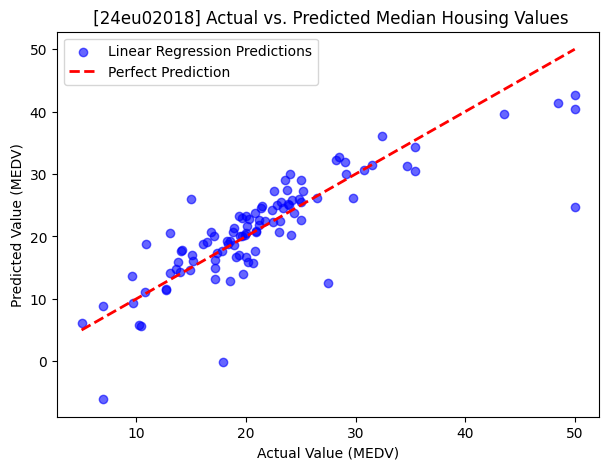

In [14]:
import matplotlib.pyplot as plt

# Generate predictions
lr_predictions = lr_model.predict(x_test)

# Plot Actual vs Predicted
plt.figure(figsize=(7,5))

plt.scatter(y_test, lr_predictions,
            color='blue',
            alpha=0.6,
            label='Linear Regression Predictions')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--',
         lw=2,
         label='Perfect Prediction')

plt.title(" [24eu02018] Actual vs. Predicted Median Housing Values")
plt.xlabel("Actual Value (MEDV)")
plt.ylabel("Predicted Value (MEDV)")
plt.legend()

plt.show()

# Task 2: Implement Support Vector Regression and Decision Tree Regression models for comparative performance analysis (Suggested Dataset: Boston Housing Dataset).

In [15]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

#Feature Scaling
scale=StandardScaler()
x_train_scale= scale.fit_transform(x_train)
x_test_scale= scale.fit_transform(x_test)

#Create and train the SVR model
svr= SVR(kernel='rbf')
svr.fit(x_train_scale, y_train)

#Predict the output
svr_predictions=svr.predict(x_test_scale)

#Calculate performance metrics
svr_mae=mean_absolute_error(y_test, svr_predictions)
svr_mse=mean_squared_error(y_test, svr_predictions)
svr_rmse=np.sqrt(svr_mse)
svr_r2=r2_score(y_test, svr_predictions)

#Display results
print("Support Vector Regression Performance Metrics")
print("---------------------------------------------")
print(f"Mean Absolute Error (MAE)      : {svr_mae:.4f}")
print(f"Mean Squared Error (MSE)       : {svr_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {svr_rmse:.4f}")
print(f"R² Score                       : {svr_r2:.4f}")

Support Vector Regression Performance Metrics
---------------------------------------------
Mean Absolute Error (MAE)      : 3.1720
Mean Squared Error (MSE)       : 28.2905
Root Mean Squared Error (RMSE) : 5.3189
R² Score                       : 0.6142


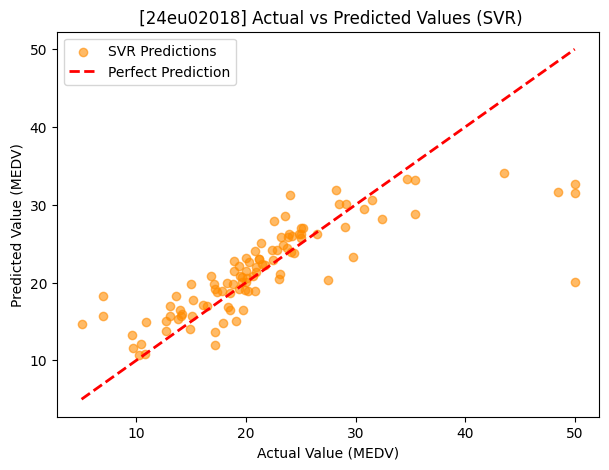

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, svr_predictions,
            color='darkorange',
            alpha=0.6,
            label='SVR Predictions')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--',
         lw=2,
         label='Perfect Prediction')

plt.title(" [24eu02018] Actual vs Predicted Values (SVR)")
plt.xlabel("Actual Value (MEDV)")
plt.ylabel("Predicted Value (MEDV)")
plt.legend()

plt.show()

# DECISION TREES

In [17]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

#create the model
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)

#Predict the output
dt_predictions= dt.predict(x_test)

# Calculate performance metrics
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

# Display results
print("Decision Tree Regression Performance Metrics")
print("--------------------------------------------")
print(f"Mean Absolute Error (MAE)      : {dt_mae:.4f}")
print(f"Mean Squared Error (MSE)       : {dt_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {dt_rmse:.4f}")
print(f"R² Score                       : {dt_r2:.4f}")

Decision Tree Regression Performance Metrics
--------------------------------------------
Mean Absolute Error (MAE)      : 2.7118
Mean Squared Error (MSE)       : 22.2520
Root Mean Squared Error (RMSE) : 4.7172
R² Score                       : 0.6966


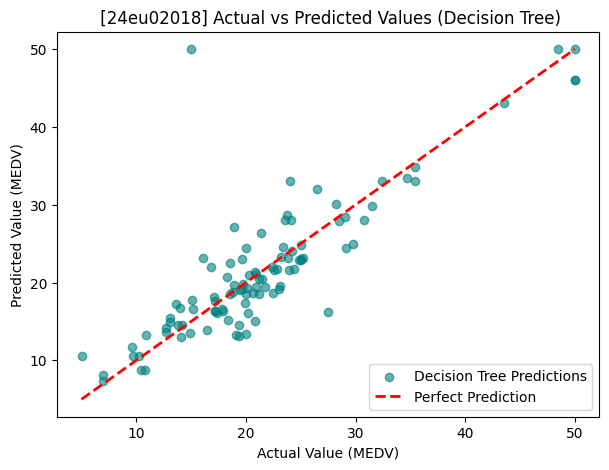

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, dt_predictions,
            color='teal',
            alpha=0.6,
            label='Decision Tree Predictions')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--',
         lw=2,
         label='Perfect Prediction')

plt.title(" [24eu02018] Actual vs Predicted Values (Decision Tree)")
plt.xlabel("Actual Value (MEDV)")
plt.ylabel("Predicted Value (MEDV)")
plt.legend()

plt.show()

# Task 3: Evaluate regression models using learning curves and appropriate error metrics
Continuous Evaluation and Diagnostic Metrics across All Models

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd


# Performance metrics for Linear Regression
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_predictions)

# Performance metrics for Support Vector Regression
svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_predictions)

# Performance metrics for Decision Tree Regression
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

# Create a comparison table
performance = pd.DataFrame({
    "Model": ["Linear Regression", "Support Vector Regression", "Decision Tree Regression"],
    "MAE": [lr_mae, svr_mae, dt_mae],
    "MSE": [lr_mse, svr_mse, dt_mse],
    "RMSE": [lr_rmse, svr_rmse, dt_rmse],
    "R² Score": [lr_r2, svr_r2, dt_r2]
})

print("Regression Model Performance Comparison")
print(performance)

Regression Model Performance Comparison
                       Model       MAE        MSE      RMSE  R² Score
0          Linear Regression  3.189092  24.291119  4.928602  0.668759
1  Support Vector Regression  3.171950  28.290476  5.318879  0.614223
2   Decision Tree Regression  2.711765  22.251961  4.717198  0.696566
